## Set up environment

In [39]:
import pandas as pd
import numpy as np
pd.set_option('display.max_columns', None) # show all columns

In [40]:
# prompt: google drive

from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [41]:
df = pd.read_csv('/content/drive/MyDrive/MLC_Final_Project/Data/ACS Data/ACS_update.csv')

### Clean data

In [42]:
df.head()

,zcta,year,merge_key,number_of_households,household_median_income_1yr,household_mean_income_1yr,number_of_rent_home,median_rent,number_of_owned_home,median_home_value,population_25_and_over,less_than_9th_grade,9th_to_12th_grade,high_school_graduate,some_college_no_degree,associates_degree,bachelors_degree,graduate_or_professional_degree,total_population,pct_children_teens_5-19,pct_young_adults_20-34,pct_middle_aged_35-59,pct_older_adults_60+,housing_units,pct_1_person,pct_2_person,pct_3_person,pct_4_or_more_person
0,10001,2023,2023_10001,15097,123393,205444,11399,3024,3570,793000,22724,2.112304,5.034325,8.638444,9.514170,3.199261,41.471572,30.029924,29079,10.653736,20.898243,41.916847,20.898243,15097,55.010929,29.297211,9.518447,6.173412
1,10002,2023,2023_10002,35771,46525,93314,28916,1207,6660,808500,59418,13.788751,15.215928,17.723585,10.347033,3.970177,26.542462,12.412064,75517,11.974787,15.850736,33.393805,32.453620,35771,44.222974,33.211261,12.521316,10.044449
2,10003,2023,2023_10003,25080,153750,248577,16196,2772,8701,1137000,36544,2.982706,1.313485,4.802430,6.170644,2.531195,44.729641,37.469899,53825,17.103576,25.629354,30.918718,21.935903,25080,53.337321,32.149123,10.071770,4.441786
3,10004,2023,2023_10004,1775,220592,309645,1145,3501,630,1866400,3010,0.531561,0.365449,1.661130,6.378738,0.166113,42.624585,48.272425,3875,11.561290,16.077419,48.103226,14.090323,1775,40.338028,30.366197,15.718310,13.577465
4,10005,2023,2023_10005,5156,211810,279387,4276,3501,880,1387200,7325,0.887372,1.665529,5.870307,6.484642,0.832765,50.552901,33.706485,9238,5.877896,35.570470,45.605109,9.092877,5156,53.316524,31.400310,7.059736,8.223429


In [43]:
print(df.columns)
print(df.shape)

Index(['zcta', 'year', 'merge_key', 'number_of_households',
       'household_median_income_1yr', 'household_mean_income_1yr',
       'number_of_rent_home', 'median_rent', 'number_of_owned_home',
       'median_home_value', 'population_25_and_over', 'less_than_9th_grade',
       '9th_to_12th_grade', 'high_school_graduate', 'some_college_no_degree',
       'associates_degree', 'bachelors_degree',
       'graduate_or_professional_degree', 'total_population',
       'pct_children_teens_5-19', 'pct_young_adults_20-34',
       'pct_middle_aged_35-59', 'pct_older_adults_60+', 'housing_units',
       'pct_1_person', 'pct_2_person', 'pct_3_person', 'pct_4_or_more_person'],
      dtype='object')
(2348, 28)


In [44]:
# Columns to check
cols_to_check = ['household_median_income_1yr', 'median_rent']

# Strange values definition
strange_values = [-666666666, 0]

# Condition: if any of the two columns is null, -6666666, or 0
cond_strange = (
    df[cols_to_check].isna().any(axis=1) |
    (df[cols_to_check].isin(strange_values).any(axis=1))
)

# Get the full rows where strange values occur
strange_rows = df[cond_strange]

# Show the strange rows
print(strange_rows)
print(strange_rows.shape)

       zcta  year   merge_key  number_of_households  \
17    10020  2023  2023_10020                     0   
42    10103  2023  2023_10103                     0   
43    10110  2023  2023_10110                     0   
44    10111  2023  2023_10111                     0   
45    10112  2023  2023_10112                     0   
...     ...   ...         ...                   ...   
2308  11371  2013  2013_11371                     0   
2330  11424  2013  2013_11424                     0   
2331  11425  2013  2013_11425                     0   
2336  11430  2013  2013_11430                     0   
2342  11451  2013  2013_11451                     0   

      household_median_income_1yr  household_mean_income_1yr  \
17                     -666666666                 -666666666   
42                     -666666666                 -666666666   
43                     -666666666                 -666666666   
44                     -666666666                 -666666666   
45                 

In [45]:
# Remove strange rows
df_cleaned = df[~cond_strange].copy()

# (Optional) Reset index
df_cleaned.reset_index(drop=True, inplace=True)

In [46]:
print(df_cleaned.head())
print(df_cleaned.shape)

    zcta  year   merge_key  number_of_households  household_median_income_1yr  \
0  10001  2023  2023_10001                 15097                       123393   
1  10002  2023  2023_10002                 35771                        46525   
2  10003  2023  2023_10003                 25080                       153750   
3  10004  2023  2023_10004                  1775                       220592   
4  10005  2023  2023_10005                  5156                       211810   

   household_mean_income_1yr  number_of_rent_home  median_rent  \
0                     205444                11399         3024   
1                      93314                28916         1207   
2                     248577                16196         2772   
3                     309645                 1145         3501   
4                     279387                 4276         3501   

   number_of_owned_home  median_home_value  population_25_and_over  \
0                  3570             793000    

In [47]:
# Find rows where any column is -666666666
rows_with_minus_666666666 = df_cleaned[(df_cleaned == -666666666).any(axis=1)]

# Display them
rows_with_minus_666666666

,zcta,year,merge_key,number_of_households,household_median_income_1yr,household_mean_income_1yr,number_of_rent_home,median_rent,number_of_owned_home,median_home_value,population_25_and_over,less_than_9th_grade,9th_to_12th_grade,high_school_graduate,some_college_no_degree,associates_degree,bachelors_degree,graduate_or_professional_degree,total_population,pct_children_teens_5-19,pct_young_adults_20-34,pct_middle_aged_35-59,pct_older_adults_60+,housing_units,pct_1_person,pct_2_person,pct_3_person,pct_4_or_more_person
33,10037,2023,2023_10037,10205,51250,88255,9245,1406,912,-666666666,14375,7.151304,6.810435,23.902609,13.523478,5.433043,25.718261,17.460870,18333,13.358425,11.465663,39.786178,27.982327,10205,59.480647,26.369427,7.300343,6.849584
42,10162,2023,2023_10162,883,110349,138519,814,3501,0,-666666666,1349,0.000000,1.853225,28.391401,1.334322,3.928836,30.911787,33.580430,1769,7.235726,2.600339,25.833804,48.841153,883,46.206116,34.541336,2.151755,17.100793
43,10279,2023,2023_10279,62,250001,1210208,62,3501,0,-666666666,129,0.000000,0.000000,0.000000,0.000000,16.279070,61.240310,22.480620,181,0.000000,0.000000,49.723757,21.546961,62,0.000000,54.838710,0.000000,45.161290
81,10474,2023,2023_10474,3917,41279,58859,3504,1406,330,-666666666,6842,15.302543,11.341713,33.484361,19.190295,5.685472,9.441684,5.553932,11188,22.801216,15.641759,36.431891,18.037183,3917,28.644371,30.788869,15.573143,24.993618
215,10037,2022,2022_10037,10103,50177,79169,9397,1470,683,-666666666,14386,6.089253,6.881691,23.286529,13.638259,6.311692,25.288475,18.504101,19138,13.663915,12.195632,38.713554,25.875222,10103,56.992972,25.824013,8.749876,8.433139
224,10162,2022,2022_10162,896,105391,127122,877,3501,0,-666666666,1286,0.000000,5.987558,26.360809,0.000000,1.477449,35.303266,30.870918,1523,5.515430,5.975049,18.450427,56.204859,896,52.343750,33.816964,5.691964,8.147321
225,10279,2022,2022_10279,75,250001,1605259,75,3501,0,-666666666,161,0.000000,0.000000,0.000000,31.677019,11.180124,29.192547,27.950311,161,0.000000,0.000000,80.124224,19.875776,75,0.000000,100.000000,0.000000,0.000000
397,10037,2021,2021_10037,9922,48782,73954,9285,1350,617,-666666666,14546,5.431046,7.617214,25.429671,12.704524,5.121683,25.202805,18.493057,19374,13.069062,12.547744,38.634252,25.095489,9922,54.434590,27.494457,9.232010,8.838944
406,10162,2021,2021_10162,1208,99300,146926,1133,3068,0,-666666666,1642,0.000000,5.846529,25.700365,0.000000,4.567600,42.143727,21.741778,2268,6.305115,5.996473,38.888889,24.514991,1208,51.158940,27.400662,8.940397,12.500000
588,10162,2020,2020_10162,622,96555,147342,566,3073,0,-666666666,904,0.000000,3.650442,33.517699,0.000000,6.194690,34.402655,22.234513,1240,5.080645,2.258065,35.967742,32.016129,622,37.299035,39.871383,6.430868,16.398714


In [48]:
import numpy as np

# Step 1: Replace -666666666 with NaN
df_cleaned.replace([-666666666, -888888888], np.nan, inplace=True)


In [49]:
df_cleaned[df_cleaned['merge_key'].isin(['2023_10037', '2023_10162'])]

,zcta,year,merge_key,number_of_households,household_median_income_1yr,household_mean_income_1yr,number_of_rent_home,median_rent,number_of_owned_home,median_home_value,population_25_and_over,less_than_9th_grade,9th_to_12th_grade,high_school_graduate,some_college_no_degree,associates_degree,bachelors_degree,graduate_or_professional_degree,total_population,pct_children_teens_5-19,pct_young_adults_20-34,pct_middle_aged_35-59,pct_older_adults_60+,housing_units,pct_1_person,pct_2_person,pct_3_person,pct_4_or_more_person
33,10037,2023,2023_10037,10205,51250,88255,9245,1406.0,912,NaN,14375,7.151304,6.810435,23.902609,13.523478,5.433043,25.718261,17.46087,18333,13.358425,11.465663,39.786178,27.982327,10205,59.480647,26.369427,7.300343,6.849584
42,10162,2023,2023_10162,883,110349,138519,814,3501.0,0,NaN,1349,0.000000,1.853225,28.391401,1.334322,3.928836,30.911787,33.58043,1769,7.235726,2.600339,25.833804,48.841153,883,46.206116,34.541336,2.151755,17.100793


In [50]:
df_cleaned

,zcta,year,merge_key,number_of_households,household_median_income_1yr,household_mean_income_1yr,number_of_rent_home,median_rent,number_of_owned_home,median_home_value,population_25_and_over,less_than_9th_grade,9th_to_12th_grade,high_school_graduate,some_college_no_degree,associates_degree,bachelors_degree,graduate_or_professional_degree,total_population,pct_children_teens_5-19,pct_young_adults_20-34,pct_middle_aged_35-59,pct_older_adults_60+,housing_units,pct_1_person,pct_2_person,pct_3_person,pct_4_or_more_person
0,10001,2023,2023_10001,15097,123393,205444,11399,3024.0,3570,793000.0,22724,2.112304,5.034325,8.638444,9.514170,3.199261,41.471572,30.029924,29079,10.653736,20.898243,41.916847,20.898243,15097,55.010929,29.297211,9.518447,6.173412
1,10002,2023,2023_10002,35771,46525,93314,28916,1207.0,6660,808500.0,59418,13.788751,15.215928,17.723585,10.347033,3.970177,26.542462,12.412064,75517,11.974787,15.850736,33.393805,32.453620,35771,44.222974,33.211261,12.521316,10.044449
2,10003,2023,2023_10003,25080,153750,248577,16196,2772.0,8701,1137000.0,36544,2.982706,1.313485,4.802430,6.170644,2.531195,44.729641,37.469899,53825,17.103576,25.629354,30.918718,21.935903,25080,53.337321,32.149123,10.071770,4.441786
3,10004,2023,2023_10004,1775,220592,309645,1145,3501.0,630,1866400.0,3010,0.531561,0.365449,1.661130,6.378738,0.166113,42.624585,48.272425,3875,11.561290,16.077419,48.103226,14.090323,1775,40.338028,30.366197,15.718310,13.577465
4,10005,2023,2023_10005,5156,211810,279387,4276,3501.0,880,1387200.0,7325,0.887372,1.665529,5.870307,6.484642,0.832765,50.552901,33.706485,9238,5.877896,35.570470,45.605109,9.092877,5156,53.316524,31.400310,7.059736,8.223429
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1989,11691,2013,2013_11691,18942,39409,56640,13955,1012.0,4825,448200.0,35984,12.500000,14.400000,28.300000,16.900000,6.400000,13.500000,8.000000,61091,21.800000,15.600000,29.600000,20.500000,18942,29.100000,22.400000,15.200000,33.200000
1990,11692,2013,2013_11692,5974,43354,60455,3918,875.0,2000,355800.0,11102,10.700000,13.600000,28.700000,19.900000,7.800000,13.000000,6.200000,17674,22.000000,13.800000,34.700000,20.700000,5974,26.400000,23.100000,23.100000,27.300000
1991,11693,2013,2013_11693,4518,50570,60995,2419,831.0,1992,323100.0,7664,3.400000,15.500000,30.200000,19.500000,7.400000,17.200000,6.600000,11335,19.700000,12.100000,38.500000,23.100000,4518,31.600000,30.100000,18.300000,19.900000
1992,11694,2013,2013_11694,8190,76944,93633,3494,1161.0,4570,623200.0,15705,5.100000,6.900000,22.700000,19.200000,8.400000,19.800000,17.700000,21725,19.100000,9.000000,35.100000,29.100000,8190,32.500000,28.000000,17.700000,21.800000


In [51]:
df_cleaned.to_csv('ACS_cleaned.csv', index=False)

### change pct to num

In [52]:
df_cl_num = df_cleaned.copy()

In [53]:
df_cl_num.head()

,zcta,year,merge_key,number_of_households,household_median_income_1yr,household_mean_income_1yr,number_of_rent_home,median_rent,number_of_owned_home,median_home_value,population_25_and_over,less_than_9th_grade,9th_to_12th_grade,high_school_graduate,some_college_no_degree,associates_degree,bachelors_degree,graduate_or_professional_degree,total_population,pct_children_teens_5-19,pct_young_adults_20-34,pct_middle_aged_35-59,pct_older_adults_60+,housing_units,pct_1_person,pct_2_person,pct_3_person,pct_4_or_more_person
0,10001,2023,2023_10001,15097,123393,205444,11399,3024.0,3570,793000.0,22724,2.112304,5.034325,8.638444,9.514170,3.199261,41.471572,30.029924,29079,10.653736,20.898243,41.916847,20.898243,15097,55.010929,29.297211,9.518447,6.173412
1,10002,2023,2023_10002,35771,46525,93314,28916,1207.0,6660,808500.0,59418,13.788751,15.215928,17.723585,10.347033,3.970177,26.542462,12.412064,75517,11.974787,15.850736,33.393805,32.453620,35771,44.222974,33.211261,12.521316,10.044449
2,10003,2023,2023_10003,25080,153750,248577,16196,2772.0,8701,1137000.0,36544,2.982706,1.313485,4.802430,6.170644,2.531195,44.729641,37.469899,53825,17.103576,25.629354,30.918718,21.935903,25080,53.337321,32.149123,10.071770,4.441786
3,10004,2023,2023_10004,1775,220592,309645,1145,3501.0,630,1866400.0,3010,0.531561,0.365449,1.661130,6.378738,0.166113,42.624585,48.272425,3875,11.561290,16.077419,48.103226,14.090323,1775,40.338028,30.366197,15.718310,13.577465
4,10005,2023,2023_10005,5156,211810,279387,4276,3501.0,880,1387200.0,7325,0.887372,1.665529,5.870307,6.484642,0.832765,50.552901,33.706485,9238,5.877896,35.570470,45.605109,9.092877,5156,53.316524,31.400310,7.059736,8.223429


In [54]:
'''
population_25_and_over', 'less_than_9th_grade',
       '9th_to_12th_grade', 'high_school_graduate', 'some_college_no_degree',
       'associates_degree', 'bachelors_degree',
       'graduate_or_professional_degree', 'total_population',
       'pct_children_teens_5-19', 'pct_young_adults_20-34',
       'pct_middle_aged_35-59', 'pct_older_adults_60+', 'housing_units',
       'pct_1_person', 'pct_2_person', 'pct_3_person', 'pct_4_or_more_person'
'''

"\npopulation_25_and_over', 'less_than_9th_grade',\n       '9th_to_12th_grade', 'high_school_graduate', 'some_college_no_degree',\n       'associates_degree', 'bachelors_degree',\n       'graduate_or_professional_degree', 'total_population',\n       'pct_children_teens_5-19', 'pct_young_adults_20-34',\n       'pct_middle_aged_35-59', 'pct_older_adults_60+', 'housing_units',\n       'pct_1_person', 'pct_2_person', 'pct_3_person', 'pct_4_or_more_person'\n"

In [55]:
# Convert pct_children_teens_5-19 to number of people
df_cl_num['less_than_9th_grade'] = df_cl_num['less_than_9th_grade'] / 100 * df_cl_num['population_25_and_over']
df_cl_num['9th_to_12th_grade'] = df_cl_num['9th_to_12th_grade'] / 100 * df_cl_num['population_25_and_over']
df_cl_num['high_school_graduate'] = df_cl_num['high_school_graduate'] / 100 * df_cl_num['population_25_and_over']
df_cl_num['some_college_no_degree'] = df_cl_num['some_college_no_degree'] / 100 * df_cl_num['population_25_and_over']
df_cl_num['associates_degree'] = df_cl_num['associates_degree'] / 100 * df_cl_num['population_25_and_over']
df_cl_num['bachelors_degree'] = df_cl_num['bachelors_degree'] / 100 * df_cl_num['population_25_and_over']
df_cl_num['graduate_or_professional_degree'] = df_cl_num['graduate_or_professional_degree'] / 100 * df_cl_num['population_25_and_over']
df_cl_num['pct_children_teens_5-19'] = df_cl_num['pct_children_teens_5-19'] / 100 * df_cl_num['total_population']
df_cl_num['pct_young_adults_20-34'] = df_cl_num['pct_young_adults_20-34'] / 100 * df_cl_num['total_population']
df_cl_num['pct_middle_aged_35-59'] = df_cl_num['pct_middle_aged_35-59'] / 100 * df_cl_num['total_population']
df_cl_num['pct_older_adults_60+'] = df_cl_num['pct_older_adults_60+'] / 100 * df_cl_num['total_population']
df_cl_num['pct_1_person'] = df_cl_num['pct_1_person'] / 100 * df_cl_num['housing_units']
df_cl_num['pct_2_person'] = df_cl_num['pct_2_person'] / 100 * df_cl_num['housing_units']
df_cl_num['pct_3_person'] = df_cl_num['pct_3_person'] / 100 * df_cl_num['housing_units']
df_cl_num['pct_4_or_more_person'] = df_cl_num['pct_4_or_more_person'] / 100 * df_cl_num['housing_units']



In [56]:
df_cl_num

,zcta,year,merge_key,number_of_households,household_median_income_1yr,household_mean_income_1yr,number_of_rent_home,median_rent,number_of_owned_home,median_home_value,population_25_and_over,less_than_9th_grade,9th_to_12th_grade,high_school_graduate,some_college_no_degree,associates_degree,bachelors_degree,graduate_or_professional_degree,total_population,pct_children_teens_5-19,pct_young_adults_20-34,pct_middle_aged_35-59,pct_older_adults_60+,housing_units,pct_1_person,pct_2_person,pct_3_person,pct_4_or_more_person
0,10001,2023,2023_10001,15097,123393,205444,11399,3024.0,3570,793000.0,22724,480.000,1144.000,1963.000,2162.000,727.000,9424.000,6824.000,29079,3098.000,6077.000,12189.000,6077.000,15097,8305.000,4423.000,1437.000,932.000
1,10002,2023,2023_10002,35771,46525,93314,28916,1207.0,6660,808500.0,59418,8193.000,9041.000,10531.000,6148.000,2359.000,15771.000,7375.000,75517,9043.000,11970.000,25218.000,24508.000,35771,15819.000,11880.000,4479.000,3593.000
2,10003,2023,2023_10003,25080,153750,248577,16196,2772.0,8701,1137000.0,36544,1090.000,480.000,1755.000,2255.000,925.000,16346.000,13693.000,53825,9206.000,13795.000,16642.000,11807.000,25080,13377.000,8063.000,2526.000,1114.000
3,10004,2023,2023_10004,1775,220592,309645,1145,3501.0,630,1866400.0,3010,16.000,11.000,50.000,192.000,5.000,1283.000,1453.000,3875,448.000,623.000,1864.000,546.000,1775,716.000,539.000,279.000,241.000
4,10005,2023,2023_10005,5156,211810,279387,4276,3501.0,880,1387200.0,7325,65.000,122.000,430.000,475.000,61.000,3703.000,2469.000,9238,543.000,3286.000,4213.000,840.000,5156,2749.000,1619.000,364.000,424.000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1989,11691,2013,2013_11691,18942,39409,56640,13955,1012.0,4825,448200.0,35984,4498.000,5181.696,10183.472,6081.296,2302.976,4857.840,2878.720,61091,13317.838,9530.196,18082.936,12523.655,18942,5512.122,4243.008,2879.184,6288.744
1990,11692,2013,2013_11692,5974,43354,60455,3918,875.0,2000,355800.0,11102,1187.914,1509.872,3186.274,2209.298,865.956,1443.260,688.324,17674,3888.280,2439.012,6132.878,3658.518,5974,1577.136,1379.994,1379.994,1630.902
1991,11693,2013,2013_11693,4518,50570,60995,2419,831.0,1992,323100.0,7664,260.576,1187.920,2314.528,1494.480,567.136,1318.208,505.824,11335,2232.995,1371.535,4363.975,2618.385,4518,1427.688,1359.918,826.794,899.082
1992,11694,2013,2013_11694,8190,76944,93633,3494,1161.0,4570,623200.0,15705,800.955,1083.645,3565.035,3015.360,1319.220,3109.590,2779.785,21725,4149.475,1955.250,7625.475,6321.975,8190,2661.750,2293.200,1449.630,1785.420


In [57]:
'''
Index(['zcta',
       'year',
       'merge_key',
       'household_median_income_1yr',
       'median_rent',
       'less_than_9th_grade',
       '9th_to_12th_grade',
       'high_school_graduate',
       'some_college_no_degree',
       'associates_degree',
       'bachelors_degree',
       'graduate_or_professional_degree',
       'pct_children_teens_5-19',
       'pct_young_adults_20-34',
       'pct_middle_aged_35-59',
       'pct_older_adults_60+',
       'pct_1_person',
       'pct_2_person',
       'pct_3_person',
       'pct_4_or_more_person'],
      dtype='object')'''

"\nIndex(['zcta',\n       'year',\n       'merge_key',\n       'household_median_income_1yr',\n       'median_rent',\n       'less_than_9th_grade',\n       '9th_to_12th_grade',\n       'high_school_graduate',\n       'some_college_no_degree',\n       'associates_degree',\n       'bachelors_degree',\n       'graduate_or_professional_degree',\n       'pct_children_teens_5-19',\n       'pct_young_adults_20-34',\n       'pct_middle_aged_35-59',\n       'pct_older_adults_60+',\n       'pct_1_person',\n       'pct_2_person',\n       'pct_3_person',\n       'pct_4_or_more_person'],\n      dtype='object')"

### cal culate relative change

In [58]:
# List of columns you want to keep
columns_to_keep = [
    'zcta',
    'year',
    'merge_key',
    'household_median_income_1yr',
    'median_rent',
    'less_than_9th_grade',
    '9th_to_12th_grade',
    'high_school_graduate',
    'some_college_no_degree',
    'associates_degree',
    'bachelors_degree',
    'graduate_or_professional_degree',
    'pct_children_teens_5-19',
    'pct_young_adults_20-34',
    'pct_middle_aged_35-59',
    'pct_older_adults_60+',
    'pct_1_person',
    'pct_2_person',
    'pct_3_person',
    'pct_4_or_more_person'
]

# Keep only these columns
df_selected = df_cl_num[columns_to_keep].copy()

In [59]:
df_selected

,zcta,year,merge_key,household_median_income_1yr,median_rent,less_than_9th_grade,9th_to_12th_grade,high_school_graduate,some_college_no_degree,associates_degree,bachelors_degree,graduate_or_professional_degree,pct_children_teens_5-19,pct_young_adults_20-34,pct_middle_aged_35-59,pct_older_adults_60+,pct_1_person,pct_2_person,pct_3_person,pct_4_or_more_person
0,10001,2023,2023_10001,123393,3024.0,480.000,1144.000,1963.000,2162.000,727.000,9424.000,6824.000,3098.000,6077.000,12189.000,6077.000,8305.000,4423.000,1437.000,932.000
1,10002,2023,2023_10002,46525,1207.0,8193.000,9041.000,10531.000,6148.000,2359.000,15771.000,7375.000,9043.000,11970.000,25218.000,24508.000,15819.000,11880.000,4479.000,3593.000
2,10003,2023,2023_10003,153750,2772.0,1090.000,480.000,1755.000,2255.000,925.000,16346.000,13693.000,9206.000,13795.000,16642.000,11807.000,13377.000,8063.000,2526.000,1114.000
3,10004,2023,2023_10004,220592,3501.0,16.000,11.000,50.000,192.000,5.000,1283.000,1453.000,448.000,623.000,1864.000,546.000,716.000,539.000,279.000,241.000
4,10005,2023,2023_10005,211810,3501.0,65.000,122.000,430.000,475.000,61.000,3703.000,2469.000,543.000,3286.000,4213.000,840.000,2749.000,1619.000,364.000,424.000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1989,11691,2013,2013_11691,39409,1012.0,4498.000,5181.696,10183.472,6081.296,2302.976,4857.840,2878.720,13317.838,9530.196,18082.936,12523.655,5512.122,4243.008,2879.184,6288.744
1990,11692,2013,2013_11692,43354,875.0,1187.914,1509.872,3186.274,2209.298,865.956,1443.260,688.324,3888.280,2439.012,6132.878,3658.518,1577.136,1379.994,1379.994,1630.902
1991,11693,2013,2013_11693,50570,831.0,260.576,1187.920,2314.528,1494.480,567.136,1318.208,505.824,2232.995,1371.535,4363.975,2618.385,1427.688,1359.918,826.794,899.082
1992,11694,2013,2013_11694,76944,1161.0,800.955,1083.645,3565.035,3015.360,1319.220,3109.590,2779.785,4149.475,1955.250,7625.475,6321.975,2661.750,2293.200,1449.630,1785.420


In [60]:
# 1. Make sure your data is sorted if necessary (optional)
df_selected = df_selected.sort_values(['zcta', 'year'])

# Calculate relative rent change per zcta
df_selected['rent_change'] = (
    df_selected['median_rent'] / df_selected.groupby('zcta')['median_rent'].transform('first')
) - 1

# 3. Check result
print(df_selected[['zcta', 'year', 'median_rent', 'rent_change']].head(11))

       zcta  year  median_rent  rent_change
1812  10001  2013       1830.0     0.000000
1630  10001  2014       1865.0     0.019126
1448  10001  2015       1989.0     0.086885
1267  10001  2016       2114.0     0.155191
1087  10001  2017       1912.0     0.044809
907   10001  2018       2065.0     0.128415
727   10001  2019       2128.0     0.162842
546   10001  2020       2169.0     0.185246
364   10001  2021       2269.0     0.239891
182   10001  2022       2625.0     0.434426
0     10001  2023       3024.0     0.652459


In [61]:
# Create a new column based on rent_change
df_selected['high_rent_growth'] = df_selected['rent_change'].apply(lambda x: 'yes' if x > 0.22 else 'no')

In [62]:
# 1. Make sure your data is sorted if necessary (optional)
df_selected = df_selected.sort_values(['zcta', 'year'])

# Calculate relative rent change per zcta
df_selected['income_change'] = (
    df_selected['household_median_income_1yr'] / df_selected.groupby('zcta')['household_median_income_1yr'].transform('first')
) - 1

# 3. Check result
print(df_selected[['zcta', 'year', 'household_median_income_1yr', 'income_change']].head(11))

       zcta  year  household_median_income_1yr  income_change
1812  10001  2013                        81671       0.000000
1630  10001  2014                        81445      -0.002767
1448  10001  2015                        86801       0.062813
1267  10001  2016                        85168       0.042818
1087  10001  2017                        85221       0.043467
907   10001  2018                        88526       0.083934
727   10001  2019                        92840       0.136756
546   10001  2020                        96787       0.185084
364   10001  2021                       101409       0.241677
182   10001  2022                       106509       0.304123
0     10001  2023                       123393       0.510855


In [63]:
# Create a new column based on income_change
df_selected['high_income_growth'] = df_selected['income_change'].apply(lambda x: 'yes' if x > 0.2 else 'no')

In [64]:
# # 1. Make sure your data is sorted if necessary (optional)
# df_selected = df_selected.sort_values(['zcta', 'year'])

# # Calculate relative income change per zcta
# df_selected['yd_pop_change'] = (
#     df_selected['pct_young_adults_20-34'] / df_selected.groupby('zcta')['pct_young_adults_20-34'].transform('first')
# ) - 1

# # 3. Check result
# print(df_selected[['zcta', 'year', 'pct_young_adults_20-34', 'yd_pop_change']].head(11))

In [65]:
# Create a new column based on yd_pop_change
# df_selected['high_youngadults_growth'] = df_selected['yd_pop_change'].apply(lambda x: 'yes' if x > 0.05 else 'no')

In [66]:
# Create 'is_gentrified' column based on two conditions
# df_selected['is_gentrified'] = np.where(
#    (df_selected['high_rent_growth'] == 'yes') & (df_selected['high_income_growth'] == 'yes') & (df_selected['high_youngadults_growth'] == 'yes'),
#    'yes',
#    'no'
#)

In [67]:
# Create 'is_gentrified' column based on two conditions
df_selected['is_gentrified'] = np.where(
    (df_selected['high_rent_growth'] == 'yes') & (df_selected['high_income_growth'] == 'yes'),
    # (df_selected['high_rent_growth'] == 'yes'),
    'yes',
    'no'
)

In [68]:
df_selected.head(11)

,zcta,year,merge_key,household_median_income_1yr,median_rent,less_than_9th_grade,9th_to_12th_grade,high_school_graduate,some_college_no_degree,associates_degree,bachelors_degree,graduate_or_professional_degree,pct_children_teens_5-19,pct_young_adults_20-34,pct_middle_aged_35-59,pct_older_adults_60+,pct_1_person,pct_2_person,pct_3_person,pct_4_or_more_person,rent_change,high_rent_growth,income_change,high_income_growth,is_gentrified
1812,10001,2013,2013_10001,81671,1830.0,650.916,635.040,1333.584,1730.484,508.032,5953.500,5048.568,2504.124,5733.126,8127.420,4546.962,6041.152,3274.128,970.112,727.584,0.000000,no,0.000000,no,no
1630,10001,2014,2014_10001,81445,1865.0,800.072,587.808,1665.456,1616.472,457.184,6057.688,5143.320,2754.807,5851.119,8514.858,4712.769,6031.260,3194.334,1161.576,781.830,0.019126,no,-0.002767,no,no
1448,10001,2015,2015_10001,86801,1989.0,736.000,623.000,2314.000,1669.000,365.000,5932.000,5509.000,3036.273,5413.510,9061.745,5225.214,6238.504,3410.227,1198.817,791.452,0.086885,no,0.062813,no,no
1267,10001,2016,2016_10001,85168,2114.0,658.000,568.000,2352.000,1616.000,382.000,6249.000,5546.000,2893.168,5273.032,9286.136,5179.704,6593.817,3446.496,1112.931,813.756,0.155191,no,0.042818,no,no
1087,10001,2017,2017_10001,85221,1912.0,572.000,522.000,2151.000,1634.000,428.000,6963.000,5569.000,2962.000,5459.000,9168.000,5496.000,6554.000,3907.000,1133.000,753.000,0.044809,no,0.043467,no,no
907,10001,2018,2018_10001,88526,2065.0,763.000,720.000,2219.000,1462.000,588.000,6810.000,5423.000,2399.000,5164.000,8911.000,5519.000,6710.000,3897.000,1072.000,752.000,0.128415,no,0.083934,no,no
727,10001,2019,2019_10001,92840,2128.0,892.000,862.000,2305.000,1454.000,536.000,7560.000,5443.000,2326.000,5318.000,9458.000,5740.000,7026.000,3975.000,1248.000,748.000,0.162842,no,0.136756,no,no
546,10001,2020,2020_10001,96787,2169.0,845.000,633.000,1945.000,1431.000,579.000,8571.000,5546.000,2712.000,5054.000,10611.000,5166.000,7077.000,3913.000,1325.000,996.000,0.185246,no,0.185084,no,no
364,10001,2021,2021_10001,101409,2269.0,673.000,865.000,1771.000,1779.000,632.000,9303.000,6273.000,2720.000,5561.000,11727.000,5249.000,7966.000,4145.000,1270.000,892.000,0.239891,yes,0.241677,yes,yes
182,10001,2022,2022_10001,106509,2625.0,741.000,1189.000,1802.000,1771.000,661.000,8911.000,6128.000,2761.000,6102.000,11421.000,5400.000,8274.000,4003.000,1277.000,821.000,0.434426,yes,0.304123,yes,yes


In [69]:
df_selected.to_csv('ACS_w_gentrification.csv', index=False)

In [70]:
df_selected.columns

Index(['zcta', 'year', 'merge_key', 'household_median_income_1yr',
       'median_rent', 'less_than_9th_grade', '9th_to_12th_grade',
       'high_school_graduate', 'some_college_no_degree', 'associates_degree',
       'bachelors_degree', 'graduate_or_professional_degree',
       'pct_children_teens_5-19', 'pct_young_adults_20-34',
       'pct_middle_aged_35-59', 'pct_older_adults_60+', 'pct_1_person',
       'pct_2_person', 'pct_3_person', 'pct_4_or_more_person', 'rent_change',
       'high_rent_growth', 'income_change', 'high_income_growth',
       'is_gentrified'],
      dtype='object')

### Let's try to do prediction task

In [71]:
# Correct splitting with 'zcta' as index
train = df_selected.loc[df_selected['year'].isin([2019,2020,2021,2022])].set_index('zcta')
test = df_selected.loc[df_selected['year'] == 2023].set_index('zcta')

training_feats =  [
    'less_than_9th_grade',
    '9th_to_12th_grade',
    'high_school_graduate',
    'some_college_no_degree',
    'associates_degree',
    'bachelors_degree',
    'graduate_or_professional_degree',
    'pct_children_teens_5-19',
    'pct_young_adults_20-34',
    'pct_middle_aged_35-59',
    'pct_older_adults_60+',
    'pct_1_person',
    'pct_2_person',
    'pct_3_person',
    'pct_4_or_more_person'
]

prediction_var = 'is_gentrified'

Xtrain,ytrain = train[training_feats].values, train[prediction_var]
Xtest,ytest = test[training_feats].values, test[prediction_var]

# Convert 'no' to 0 and 'yes' to 1
ytrain = ytrain.map({'no': 0, 'yes': 1})
ytest = ytest.map({'no': 0, 'yes': 1})


In [72]:
from sklearn.ensemble import RandomForestRegressor,RandomForestClassifier
from sklearn.tree import DecisionTreeRegressor,DecisionTreeClassifier
from xgboost import XGBRegressor,XGBClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import Lasso
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score,f1_score

def run_prediction(model, params_config, nm):
    model_cv = GridSearchCV(estimator=model, param_grid=params_config, cv=3)
    model_cv.fit(Xtrain,ytrain)
    predictions = model_cv.predict(Xtest)
    probs = model_cv.predict_proba(Xtest)

    print(f'*** {nm} Accuracy: {accuracy_score(ytest, predictions)} ***')
    print(f'*** {nm} F1: {f1_score(ytest, predictions)} ***')

    if nm == '[BASELINE] NaiveBayes':
        return probs, {}, None

    feature_importances = model_cv.best_estimator_.feature_importances_
    idx_sort_topfeats = np.argsort(feature_importances)[::-1][:20]
    feat_importance_scores = {training_feats[i]:feature_importances[i] for i in idx_sort_topfeats}

    return probs, feat_importance_scores, model_cv.best_estimator_


models = [
    {
        'model': GaussianNB(),
        'params_config': {},
        'nm': '[BASELINE] NaiveBayes'
    },
    {
        'model': DecisionTreeClassifier(),
        'params_config': {
            'max_depth': [3, 5, 7],
            'min_samples_split': [2, 5, 10],
            'min_samples_leaf': [1, 2, 5]
        },
        'nm': 'Single Decision Tree'
    },
    {
        'model': RandomForestClassifier(),
        'params_config': {
            'n_estimators': [50, 100, 200, 300],
            'max_depth': [3, 5, 7],
            'min_samples_split': [2, 5, 10],
            'min_samples_leaf': [1, 2, 5]
        },
        'nm': 'Random Forests'
    },
    {
        'model': XGBClassifier(),
        'params_config': {
             'n_estimators': [50, 100, 200, 300],
             'max_depth': [3, 5, 7, 9],
             'learning_rate' :  [0.01, 0.05, 0.1, 0.2]
        },
        'nm': 'XGBoost'
    }
]

for m_config in models:

    #instantiate data params
    m_config['train'] = '<YOUR TRAINING DATA HERE (AS A DF)>'
    m_config['test'] = '<YOUR TEST DATA HERE (AS A DF)>'
    m_config['training_feats'] = '<YOUR TRAINING FEATURES HERE (AS A LIST)>'
    m_config['prediction_var'] = '<YOUR PREDICTOR FEATURE HERE (AS A STR)>'

    #run model, unpack deliverables
    p, fi, m = run_prediction(
    model=m_config['model'],
    params_config=m_config['params_config'],
    nm=m_config['nm']
)

    #print feature importance scores
    print(f'*** Feature Importance Scores *** \n {fi}')

    #record the results per dict in the list
    m_config['feature_importances'] = fi
    m_config['probs'] = p
    m_config['model'] = m

*** [BASELINE] NaiveBayes Accuracy: 0.6703296703296703 ***
*** [BASELINE] NaiveBayes F1: 0.7887323943661971 ***
*** Feature Importance Scores *** 
 {}
*** Single Decision Tree Accuracy: 0.8901098901098901 ***
*** Single Decision Tree F1: 0.9397590361445783 ***
*** Feature Importance Scores *** 
 {'bachelors_degree': np.float64(0.2269507402692309), 'pct_1_person': np.float64(0.16352866056701612), 'pct_2_person': np.float64(0.12254047762251778), 'graduate_or_professional_degree': np.float64(0.11461027885576747), 'pct_older_adults_60+': np.float64(0.08756814309858806), 'pct_3_person': np.float64(0.07397032394444117), 'pct_children_teens_5-19': np.float64(0.06879259276369493), 'associates_degree': np.float64(0.05384220580040231), 'less_than_9th_grade': np.float64(0.039092533049031895), 'high_school_graduate': np.float64(0.028794817553577923), '9th_to_12th_grade': np.float64(0.01652572137857516), 'pct_4_or_more_person': np.float64(0.0037835050971562222), 'pct_middle_aged_35-59': np.float64(

In [73]:
import pandas as pd

# Create an empty list to collect model results
results = []

# Loop through each trained model config
for m_config in models:
    model_name = m_config['nm']

    # Pull predictions
    probs = m_config['probs']

    # Accuracy and F1 (already printed during training, but now record them)
    predictions = (probs[:,1] > 0.5).astype(int) if probs.shape[1] == 2 else probs.argmax(axis=1)
    acc = accuracy_score(ytest, predictions)
    f1 = f1_score(ytest, predictions)

    # Feature importances (if available)
    top_feats = ', '.join(list(m_config['feature_importances'].keys())[:3]) if m_config['feature_importances'] else 'N/A'

    # Save everything in a dictionary
    results.append({
        'Model': model_name,
        'Accuracy': acc,
        'F1 Score': f1,
        'Top Features': top_feats
    })

# Create a nice summary DataFrame
results_df = pd.DataFrame(results)

# Sort by best F1 score (or Accuracy if you prefer)
results_df = results_df.sort_values('F1 Score', ascending=False).reset_index(drop=True)

# Show it
display(results_df)

,Model,Accuracy,F1 Score,Top Features
0,Single Decision Tree,0.890110,0.939759,"bachelors_degree, pct_1_person, pct_2_person"
1,XGBoost,0.835165,0.905660,"bachelors_degree, pct_1_person, pct_2_person"
2,Random Forests,0.807692,0.887460,"graduate_or_professional_degree, bachelors_deg..."
3,[BASELINE] NaiveBayes,0.670330,0.788732,N/A


### Visualize result

In [74]:
import geopandas as gpd
import pandas as pd
import plotly.express as px
import json
import numpy as np
from shapely.wkt import loads

# Step 1: Load and prepare NYC ZCTA shapefile
geo_zip_nyc = pd.read_csv('/content/drive/MyDrive/MLC_Final_Project/Data/ACS Data/Modified_Zip_Code_Tabulation_Areas__MODZCTA__20250427.csv')
geo_zip_nyc['zip'] = geo_zip_nyc['MODZCTA'].astype(str)
geo_zip_nyc = geo_zip_nyc.rename(columns={'the_geom': 'geometry'})
geo_zip_nyc['geometry'] = geo_zip_nyc['geometry'].apply(loads)

# Create GeoDataFrame properly
geo_zip_nyc = gpd.GeoDataFrame(geo_zip_nyc, geometry='geometry')
geo_zip_nyc.set_index('zip', inplace=True)
geo_zip_nyc.set_crs(epsg=4326, inplace=True)

# Step 2: Prepare best model results
best_model_result = models[0]  # Assuming Random Forests (highest F1)

# Step 3: Prepare hotspot scores
test.index = test.index.astype(str)  # Ensure test index is string
hotspot_scores = pd.DataFrame(
    best_model_result['probs'][:, 1],
    index=test.index,
    columns=['Gentrification Hotspot Score']
)

# Step 4: Merge geometries and scores
w_geo = gpd.GeoDataFrame(
    pd.concat([geo_zip_nyc, hotspot_scores], axis=1).dropna(),
    crs="EPSG:4326"
)

# Step 5: Reset index so 'zip' becomes a column (required for Plotly)
w_geo['zip'] = w_geo.index  # add zip column
w_geo = w_geo.reset_index(drop=True)  # reset index but keep zip

# Step 6: Prepare GeoJSON
geojson = json.loads(w_geo.to_json())

# Step 7: Calculate center properly
w_geo_projected = w_geo.to_crs(epsg=3857)
center_lat = w_geo_projected.centroid.to_crs(epsg=4326).y.mean()
center_lon = w_geo_projected.centroid.to_crs(epsg=4326).x.mean()

# Step 8: Create choropleth map
fig = px.choropleth_mapbox(
    w_geo,
    geojson=geojson,
    locations="zip",  # Now using column, not index
    color="Gentrification Hotspot Score",
    featureidkey="properties.zip",
    center={"lat": center_lat, "lon": center_lon},
    zoom=10,
    mapbox_style="carto-positron",
    color_continuous_scale="plasma",  # or 'viridis', 'magma', etc.
    hover_name="zip",
    hover_data={"Gentrification Hotspot Score": True}
)

# Step 9: Fine-tune color scaling
fig.update_layout(
    coloraxis_colorbar=dict(
        title="Gentrification Hotspot Score",
        tickformat=".2f"
    ),
    coloraxis_cmin=0.2,  # Start coloring from 20%
    coloraxis_cmax=1.0,  # Max at 100%
    margin={"r": 0, "t": 0, "l": 0, "b": 0}
)

# Step 10: Show map
fig.show()

Output hidden; open in https://colab.research.google.com to view.

In [92]:
# Extract top 20 ZIP codes by hotspot score
top_20_zipcodes = hotspot_scores.sort_values('Gentrification Hotspot Score', ascending=False).head(20)
top_20_zipcodes['zip'] = top_20_zipcodes.index  # move index to column

print("Top 20 ZIP codes with highest hotspot scores:")
print(top_20_zipcodes)

Top 10 ZIP codes with highest hotspot scores:
       Gentrification Hotspot Score    zip
zcta                                      
10025                      0.999318  10025
11215                      0.998225  11215
11201                      0.997276  11201
11221                      0.997085  11221
11385                      0.996888  11385
11375                      0.994319  11375
10024                      0.993908  10024
11226                      0.993645  11226
11235                      0.993415  11235
10314                      0.991116  10314
11234                      0.989175  11234
10023                      0.988240  10023
11238                      0.987630  11238
11230                      0.987457  11230
11211                      0.987348  11211
11206                      0.986299  11206
10128                      0.984353  10128
11236                      0.984165  11236
11209                      0.981653  11209
11216                      0.981512  11216


### Some checkings (please ignore)

In [76]:
print(w_geo.head())
print(w_geo.geometry.is_valid.all())

   MODZCTA         label                 ZCTA  pop_est  \
0  10001.0  10001, 10118  10001, 10119, 10199  23072.0   
1  10002.0         10002                10002  74993.0   
2  10003.0         10003                10003  54682.0   
3  10026.0         10026                10026  39363.0   
4  10004.0         10004                10004   3028.0   

                                            geometry  \
0  MULTIPOLYGON (((-73.98774 40.74407, -73.98819 ...   
1  MULTIPOLYGON (((-73.9975 40.71407, -73.99709 4...   
2  MULTIPOLYGON (((-73.98864 40.72293, -73.98876 ...   
3  MULTIPOLYGON (((-73.96201 40.80551, -73.96007 ...   
4  MULTIPOLYGON (((-74.00827 40.70772, -74.00937 ...   

   Gentrification Hotspot Score    zip  
0                      0.566928  10001  
1                      0.873592  10002  
2                      0.959820  10003  
3                      0.653402  10026  
4                      0.022741  10004  
True


In [77]:
# Make sure test index is string
test.index = test.index.astype(str)

In [78]:
hotspot_scores = pd.DataFrame(
    best_model_result['probs'][:,1],
    index=test.index,
    columns=['Gentrification Hotspot Score']
)

In [79]:
# Merge with geometry
w_geo = gpd.GeoDataFrame(
    pd.concat((geo_zip_nyc, hotspot_scores), axis=1).dropna(),
    crs="EPSG:4326"
)

In [80]:
print(w_geo.shape)
print(w_geo.head())

(176, 6)
       MODZCTA         label                 ZCTA  pop_est  \
10001  10001.0  10001, 10118  10001, 10119, 10199  23072.0   
10002  10002.0         10002                10002  74993.0   
10003  10003.0         10003                10003  54682.0   
10026  10026.0         10026                10026  39363.0   
10004  10004.0         10004                10004   3028.0   

                                                geometry  \
10001  MULTIPOLYGON (((-73.98774 40.74407, -73.98819 ...   
10002  MULTIPOLYGON (((-73.9975 40.71407, -73.99709 4...   
10003  MULTIPOLYGON (((-73.98864 40.72293, -73.98876 ...   
10026  MULTIPOLYGON (((-73.96201 40.80551, -73.96007 ...   
10004  MULTIPOLYGON (((-74.00827 40.70772, -74.00937 ...   

       Gentrification Hotspot Score  
10001                      0.566928  
10002                      0.873592  
10003                      0.959820  
10026                      0.653402  
10004                      0.022741  


In [81]:
print(test.index.sort_values())
print(geo_zip_nyc.index.sort_values())

Index(['10001', '10002', '10003', '10004', '10005', '10006', '10007', '10009',
       '10010', '10011',
       ...
       '11429', '11432', '11433', '11434', '11435', '11436', '11691', '11692',
       '11693', '11694'],
      dtype='object', name='zcta', length=182)
Index(['10001', '10002', '10003', '10004', '10005', '10006', '10007', '10009',
       '10010', '10011',
       ...
       '11433', '11434', '11435', '11436', '11691', '11692', '11693', '11694',
       '11697', '99999'],
      dtype='object', name='zip', length=178)


In [82]:
print(w_geo[['Gentrification Hotspot Score']].describe())

       Gentrification Hotspot Score
count                    176.000000
mean                       0.602970
std                        0.336216
min                        0.022741
25%                        0.285050
50%                        0.683818
75%                        0.915539
max                        0.999318


In [83]:
print(w_geo.sort_values('Gentrification Hotspot Score', ascending=False).head(10))

       MODZCTA  label          ZCTA   pop_est  \
10025  10025.0  10025         10025   92805.0   
11215  11215.0  11215         11215   70156.0   
11201  11201.0  11201         11201   62823.0   
11221  11221.0  11221         11221   83835.0   
11385  11385.0  11385         11385  106717.0   
11375  11375.0  11375         11375   73488.0   
10024  10024.0  10024         10024   59001.0   
11226  11226.0  11226         11226  100277.0   
11235  11235.0  11235         11235   78128.0   
10314  10314.0  10314  10311, 10314   90761.0   

                                                geometry  \
10025  MULTIPOLYGON (((-73.96701 40.78848, -73.96783 ...   
11215  MULTIPOLYGON (((-73.99823 40.6712, -73.99846 4...   
11201  MULTIPOLYGON (((-73.98999 40.68332, -73.99219 ...   
11221  MULTIPOLYGON (((-73.91604 40.68607, -73.91661 ...   
11385  MULTIPOLYGON (((-73.86891 40.69515, -73.87004 ...   
11375  MULTIPOLYGON (((-73.84315 40.70922, -73.84326 ...   
10024  MULTIPOLYGON (((-73.97407 40.7788

In [84]:
print(geojson['features'][0]['properties'])
print(geojson['features'][0]['geometry'])

{'MODZCTA': 10001.0, 'label': '10001, 10118', 'ZCTA': '10001, 10119, 10199', 'pop_est': 23072.0, 'Gentrification Hotspot Score': 0.5669277457119911, 'zip': '10001'}
{'type': 'MultiPolygon', 'coordinates': [[[[-73.98774438827894, 40.74406551211233], [-73.9881919930764, 40.74345073483949], [-73.98900752572685, 40.74379665408825], [-73.9888702675778, 40.744532233901936], [-73.99097050509715, 40.745421716595565], [-73.99141808994322, 40.74480143740416], [-73.99187288347258, 40.74418664642827], [-73.9920677930693, 40.74391767451525], [-73.99494033451634, 40.7450596524634], [-73.99759643725481, 40.74620155426619], [-73.99783463868435, 40.745877678581365], [-73.9980078654556, 40.74594904518908], [-73.99755311590617, 40.74658032872911], [-73.9988667729549, 40.74712929892797], [-74.00039699416078, 40.74776608551251], [-74.00085172499608, 40.74714576984647], [-74.00368846947988, 40.7483588928015], [-74.00424428093888, 40.748589432517285], [-74.00652531566305, 40.749555477191954], [-74.0070233062

In [85]:
featureidkey="properties.zip"

In [86]:
print(w_geo.index[:5])

Index(['10001', '10002', '10003', '10026', '10004'], dtype='object')


IndexError: index 18 is out of bounds for axis 0 with size 18

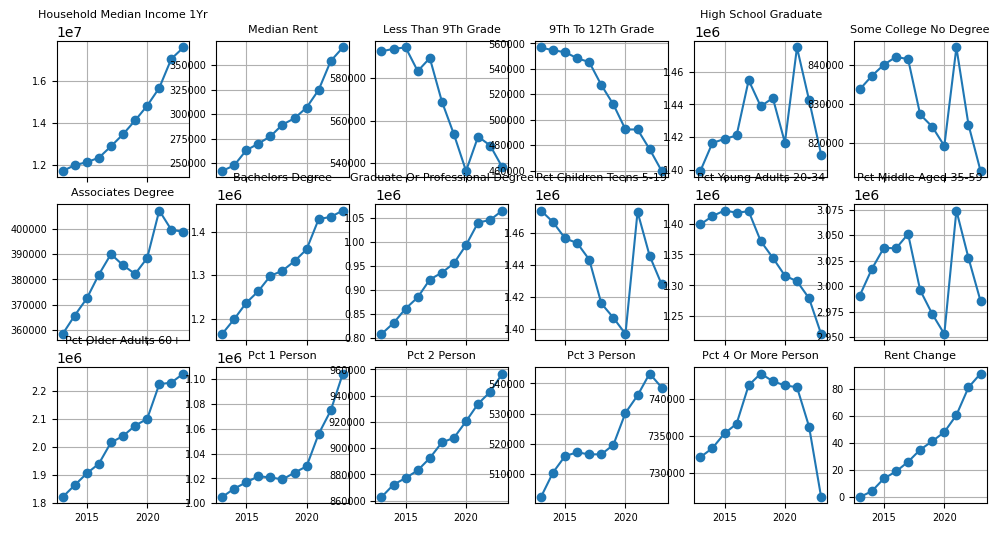

In [88]:
import pandas as pd
import matplotlib.pyplot as plt

# Assuming df_selected is already loaded
cols_to_exclude = ['zcta', 'merge_key']
numeric_cols = [col for col in df_selected.columns if col not in cols_to_exclude + ['year'] and pd.api.types.is_numeric_dtype(df_selected[col])]

# Group by year and sum across ZCTAs
df_grouped = df_selected.groupby('year')[numeric_cols].sum()

# Define 3 rows × 6 columns layout
n_rows = 3
n_cols = 6

fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 6), sharex=True)
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    axes[i].plot(df_grouped.index, df_grouped[col], marker='o', linestyle='-')
    axes[i].set_title(col.replace('_', ' ').title(), fontsize=8)
    axes[i].tick_params(labelsize=7)
    axes[i].grid(True)

# Remove unused axes
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout(h_pad=1.0, w_pad=1.0)
plt.show()

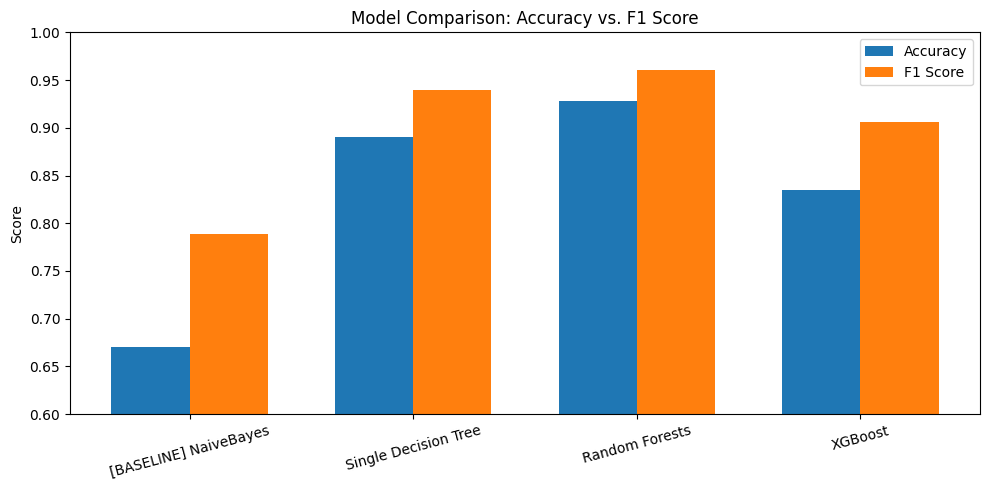

In [89]:
import matplotlib.pyplot as plt
import pandas as pd

# Model performance data
model_names = [
    '[BASELINE] NaiveBayes',
    'Single Decision Tree',
    'Random Forests',
    'XGBoost'
]

accuracies = [
    0.6703296703296703,
    0.8901098901098901,
    0.9285714285714286,
    0.8351648351648352
]

f1_scores = [
    0.7887323943661971,
    0.9397590361445783,
    0.9607250755287009,
    0.9056603773584906
]

# Create a DataFrame for easy plotting
df_results = pd.DataFrame({
    'Model': model_names,
    'Accuracy': accuracies,
    'F1 Score': f1_scores
})

# Plot
fig, ax = plt.subplots(figsize=(10, 5))
bar_width = 0.35
x = range(len(df_results))

ax.bar([i - bar_width/2 for i in x], df_results['Accuracy'], width=bar_width, label='Accuracy')
ax.bar([i + bar_width/2 for i in x], df_results['F1 Score'], width=bar_width, label='F1 Score')

ax.set_xticks(x)
ax.set_xticklabels(df_results['Model'], rotation=15)
ax.set_ylim(0.6, 1.0)
ax.set_title('Model Comparison: Accuracy vs. F1 Score')
ax.set_ylabel('Score')
ax.legend()
plt.tight_layout()

plt.show()


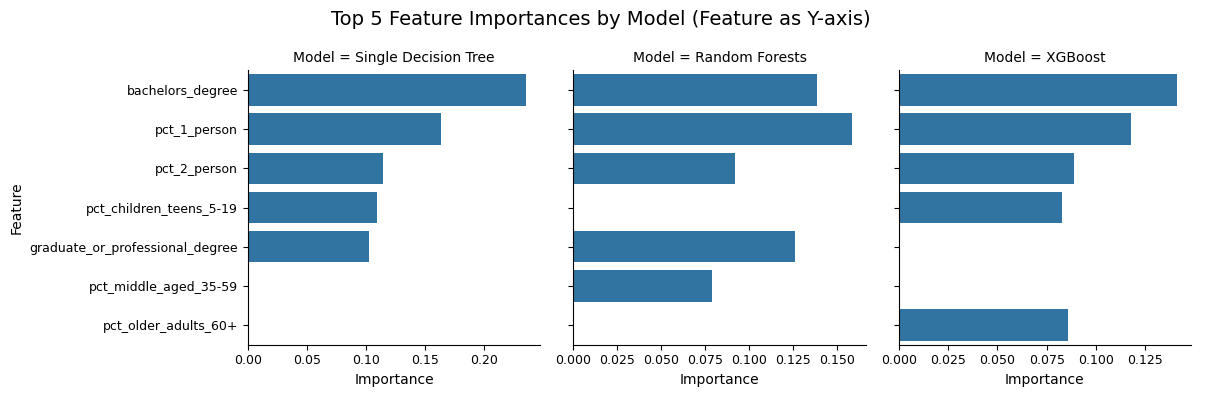

In [90]:
# Define top features manually extracted from each model (already sorted by importance)
top_features = {
    'Single Decision Tree': {
        'bachelors_degree': 0.2356,
        'pct_1_person': 0.1635,
        'pct_2_person': 0.1139,
        'pct_children_teens_5-19': 0.1092,
        'graduate_or_professional_degree': 0.1022
    },
    'Random Forests': {
        'pct_1_person': 0.1582,
        'bachelors_degree': 0.1384,
        'graduate_or_professional_degree': 0.1262,
        'pct_2_person': 0.0921,
        'pct_middle_aged_35-59': 0.0788
    },
    'XGBoost': {
        'bachelors_degree': 0.1411,
        'pct_1_person': 0.1177,
        'pct_2_person': 0.0887,
        'pct_older_adults_60+': 0.0860,
        'pct_children_teens_5-19': 0.0825
    }
}

# Redo the chart with clearer feature labels on the y-axis (already present, but we can ensure it's emphasized)
g = sns.catplot(
    data=df_feat,
    x='Importance',
    y='Feature',
    col='Model',
    kind='bar',
    col_wrap=3,
    height=4,
    sharex=False
)

# Emphasize y-axis labels
for ax in g.axes.flatten():
    ax.set_ylabel("Feature", fontsize=10)
    ax.set_xlabel("Importance", fontsize=10)
    ax.tick_params(axis='y', labelsize=9)
    ax.tick_params(axis='x', labelsize=9)

g.fig.subplots_adjust(top=0.9)
g.fig.suptitle('Top 5 Feature Importances by Model (Feature as Y-axis)', fontsize=14)
plt.tight_layout()
plt.show()


In [94]:
import geopandas as gpd
import pandas as pd
import plotly.express as px
import json
import numpy as np
from shapely.wkt import loads

# Step 1: Load and prepare NYC ZCTA shapefile
geo_zip_nyc = pd.read_csv('/content/drive/MyDrive/MLC_Final_Project/Data/ACS Data/Modified_Zip_Code_Tabulation_Areas__MODZCTA__20250427.csv')
geo_zip_nyc['zip'] = geo_zip_nyc['MODZCTA'].astype(str)
geo_zip_nyc = geo_zip_nyc.rename(columns={'the_geom': 'geometry'})
geo_zip_nyc['geometry'] = geo_zip_nyc['geometry'].apply(loads)

# Create GeoDataFrame properly
geo_zip_nyc = gpd.GeoDataFrame(geo_zip_nyc, geometry='geometry')
geo_zip_nyc.set_index('zip', inplace=True)
geo_zip_nyc.set_crs(epsg=4326, inplace=True)

# Step 2: Prepare best model results
best_model_result = models[0]  # Replace with the actual best performing model index

# Step 3: Prepare hotspot scores
test.index = test.index.astype(str)  # Ensure test index is string
hotspot_scores = pd.DataFrame(
    best_model_result['probs'][:, 1],
    index=test.index,
    columns=['Gentrification Hotspot Score']
)

# Step 4: Merge geometries and scores
w_geo = gpd.GeoDataFrame(
    pd.concat([geo_zip_nyc, hotspot_scores], axis=1).dropna(),
    crs="EPSG:4326"
)

# Step 5: Reset index so 'zip' becomes a column (required for Plotly)
w_geo['zip'] = w_geo.index
w_geo = w_geo.reset_index(drop=True)

# Step 6: Extract top 20 ZIP codes
top_20_zipcodes = hotspot_scores.sort_values('Gentrification Hotspot Score', ascending=False).head(20)
top_20_zipcodes['zip'] = top_20_zipcodes.index

# Step 7: Create a column to color only top 20 ZIPs, gray out the rest
highlight_zips = set(top_20_zipcodes['zip'])
w_geo['color_group'] = w_geo.apply(
    lambda row: row['Gentrification Hotspot Score'] if row['zip'] in highlight_zips else -1,
    axis=1
)

# Step 8: Prepare GeoJSON
geojson = json.loads(w_geo.to_json())

# Step 9: Calculate center for map
w_geo_projected = w_geo.to_crs(epsg=3857)
center_lat = w_geo_projected.centroid.to_crs(epsg=4326).y.mean()
center_lon = w_geo_projected.centroid.to_crs(epsg=4326).x.mean()

# Step 10: Plot choropleth map with top 20 colored
fig = px.choropleth_mapbox(
    w_geo,
    geojson=geojson,
    locations="zip",
    color="color_group",
    featureidkey="properties.zip",
    center={"lat": center_lat, "lon": center_lon},
    zoom=10,
    mapbox_style="carto-positron",
    color_continuous_scale="plasma",
    hover_name="zip",
    hover_data={"Gentrification Hotspot Score": True}
)

# Step 11: Adjust layout for color scale
fig.update_layout(
    coloraxis_colorbar=dict(
        title="Hotspot Score (Top 20 Only)",
        tickformat=".2f"
    ),
    coloraxis_cmin=0.2,  # Ignoring -1
    coloraxis_cmax=1.0,
    margin={"r": 0, "t": 0, "l": 0, "b": 0}
)

# Step 12: Show map
fig.show()


Output hidden; open in https://colab.research.google.com to view.